### Basis Representation Theorem

Every non-zero real number $x$ can be written uniquely as:

\begin{equation}
    \boxed{x = \text{sgn}(x) \, \beta^{p} \, \sum_{k = 1}^{+ \infty} \, d_{k} \, \beta^{-k}}
\end{equation}

Where:

- $\beta$ is the base, a natural number greater than or equal to 2
- $p$ is the exponent, an integer number (which can be zero as well)
- Each $d_k$ is a natural number less than the base $\beta$, and $d_1$ is not zero
- $\sum_{k = 1}^{+ \infty} \, d_{k} \, \beta^{-k}$ is the mantissa, a number confined within 1 / $\beta$ (strictly) and 1

The sequence $d_1, d_2, d_3, \dots$ \, does not eventually become constantly equal to $\beta$ - 1

In the IEEE 754 Standard, real numbers are represented as floats or doubles, using 32 bits or 64 bits, as shown:

- 1 bit for the sign;
- 8 or 11 bits for the exponent (with a bias of 127 for floats or 1023 for doubles) +
- 23 or 52 bits for the mantissa (with rounding rules applied)

Let's try this with the number 199,72 in float precision

1. Write 199,72 as 199 + 0,72. So, convert them separately into their binary forms

In [1]:
def integer_converter(number): # It converts an integer number into its binary form
    reminders = []
    while number != 0: # Algorithm ends when we reach zero
        r = str(number % 2) # Reminder as string
        reminders.insert(0, r) # r is inserted at the first position in the list
        number = number // 2 # Update number: x / 2 (integer division)

    return "".join(reminders) # It returns the full binary number as a string

In [2]:
s1 = integer_converter(199) # 199 in binary
s1

'11000111'

In [3]:
def decimal_converter(number, precision = 32): # It converts a real number between 0 and 1 into its binary form

    digits = []
    counter = 0 # While-cycle guard

    while (number != 0) and (counter < precision): # Precision: we cannot compute infinite digits
        number *=  2.0
        integer = int(number)
        digits.append(str(integer))
        number -= integer

        counter += 1

    return "," + "".join(digits) + "..."

In [4]:
s2 = decimal_converter(0.72) # 0.72 in binary
s2

',10111000010100011110101110000101...'

In [5]:
s = s1 + s2 # 199,72 in binary
s

'11000111,10111000010100011110101110000101...'

2. Normalize the number: write it in the form 1,...

In [6]:
exponent = len(s1) - 1 # Exponent (decimal base)
s_norm = s[0] + "," + s[1:].replace(",", "") + f" x 2^{exponent}" # 199.72 in binary form and normalized
s_norm

'1,100011110111000010100011110101110000101... x 2^7'

3. Add 127 (or 1023 for doubles) to the exponent and convert the result into its binary form. We've computed the exponent successfully

In [7]:
exponent = integer_converter(127 + exponent) # Exponent with bias 127, the result is in binary form
exponent

'10000110'

4. Extract the first 23 + 3 bits of the mantissa (52 + 3 for doubles)

In [8]:
mantissa_full = s.replace(",", "")[1:] # Full mantissa
mantissa_full

'100011110111000010100011110101110000101...'

In [9]:
mantissa_23_bits = mantissa_full[0:24] # Mantissa 23 bits (float)
mantissa_23_bits

'100011110111000010100011'

5. Check guard, round and sticky bits. Apply Standard rules

In [10]:
guard_bit = mantissa_full[25]
round_bit = mantissa_full[26]
sticky_bit = mantissa_full[27]

guard_bit, round_bit, sticky_bit

('1', '0', '1')

In our case, we must add 1 bit to the mantissa represented in 23 bits. We've computed the mantissa successfully

In [11]:
mantissa_23_bits = "10001111011100001010010" # Summed 1 in binary
mantissa_23_bits

'10001111011100001010010'

Finally, we've obtained the final result:

In [12]:
"0" + exponent + mantissa_23_bits # This is 199,72 written accordingly with the IEEE 754 Standard

'01000011010001111011100001010010'

In [13]:
len("0" + exponent + mantissa_23_bits) # 32 bits

32

This representation carries an error with it. To see this, let's retake the number 199,72 written in decimal

In [14]:
def decimal_converter(bin_str): # To convert IEEE 754 floats in decimal numbers

    sign = int(bin_str[0])  # 0 o 1
    exponent_bits = bin_str[1:9] # Exponent
    mantissa_bits = bin_str[9:] # Mantissa

    exp = int(exponent_bits, 2) - 127

    mantissa = 1.0
    for i, bit in enumerate(mantissa_bits):
        if bit == '1':
            mantissa += 2.0 ** (- (i + 1))

    sign_val = - 1.0 if sign == 1.0 else 1.0
    return sign_val * mantissa * (2.0 ** exp)

In [15]:
X = decimal_converter("0" + exponent + mantissa_23_bits) # Decimal representation
X

199.72000122070312

It's not perfectly 199,72 due to the finite representation of numbers

In [16]:
X - 199.72 # Error

1.2207031261368684e-06

In [17]:
((X - 199.72) / 199.72) * 100.0 # Relative error [%]

6.112072532229463e-07

Online converter available at: https://www.h-schmidt.net/FloatConverter/IEEE754.html

Credits: h-schmidt

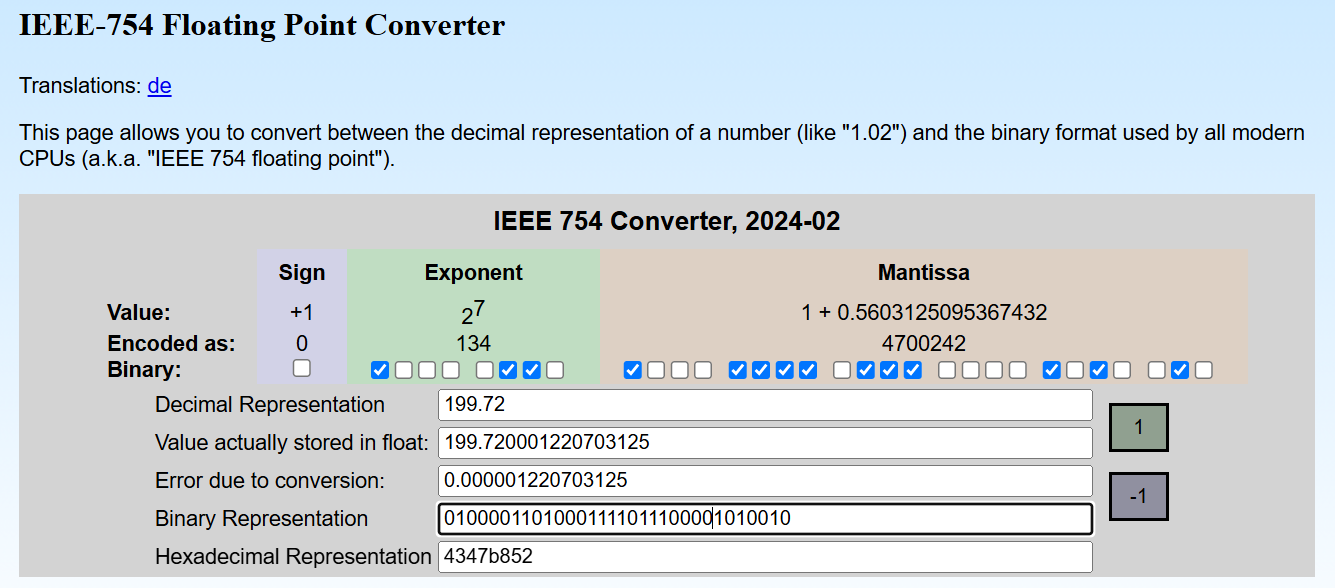